# Engine map fitting to MPC: differentiable lookup tables end-to-end

Engine torque maps are the workhorse of automotive powertrain control: a 2-D look-up of torque against engine speed and throttle, fitted to dynamometer measurements, and then queried thousands of times per second inside the cruise / launch / shift controllers above. The standard industrial toolchain (Simulink + Stateflow + Curve Fitting Toolbox + Model Predictive Control Toolbox + Design Optimization) treats each of these stages as a separate, non-differentiable artefact glued together with files on disk. In Jaxonomy the same pipeline is one JAX computation, end-to-end differentiable from the noisy dyno samples through the MPC tracking error.

In this notebook we: (i) synthesise a noisy 2-D engine map; (ii) fit it with `fit_lookup_table_2d`; (iii) optimise breakpoint *positions* with `fit_table_1d_with_grid` and watch them migrate toward curvature; (iv) drop the fitted `LookupTable2d` block into a Jaxonomy `DiagramBuilder` plant; (v) discuss the `submodel_function` mechanism that turns the plant into a pure JAX function and use the same `interp_2d` primitive (the engine of `LookupTable2d`) inside a hand-rolled short-horizon shooting MPC; and (vi) take a single `jax.grad` of the closed-loop tracking RMSE with respect to the table values, the breakpoint grid, *and* the MPC weights, all in one call.

**Estimated reading time:** 25-30 minutes. **Estimated runtime on CPU:** ~15 seconds (no GPU required).

**Prerequisites:** comfort with `DiagramBuilder` / `simulate` (see [`primitives.ipynb`](primitives.ipynb)), one prior MPC notebook ([`linear_mpc.ipynb`](linear_mpc.ipynb) is enough), and basic familiarity with `jax.grad` / `jax.jit`.

## The pipeline at a glance

We model the engine as a static map

$$\tau(\omega, u) : [\omega_{\min}, \omega_{\max}] \times [0, 1] \to \mathbb{R}_{\ge 0}, \tag{1}$$

where $\omega$ is engine speed in rad/s and $u$ is the normalised throttle command. The map is unknown; we only have $K$ noisy dynamometer measurements $\{(\omega_k, u_k, \tau_k)\}_{k=1}^K$. We represent the map as a bilinear lookup table

$$\hat\tau(\omega, u; \mathbf{xp}, \mathbf{yp}, \mathbf{Z}) = \sum_{i,j} w_{ij}(\omega, u; \mathbf{xp}, \mathbf{yp})\, Z_{ij}, \tag{2}$$

with grid breakpoints $\mathbf{xp} \in \mathbb{R}^{N_x}$, $\mathbf{yp} \in \mathbb{R}^{N_y}$, table values $\mathbf{Z} \in \mathbb{R}^{N_x \times N_y}$, and bilinear corner weights $w_{ij}$. The fit problem is a linear least-squares solve for $\mathbf{Z}$ at a fixed grid (`fit_lookup_table_2d`), or a nested inner-LS / outer-gradient problem when the grid is also free (`fit_table_1d_with_grid`).

The vehicle is a 1-DOF longitudinal model,

$$m\,\dot v = \eta\, \hat\tau(\omega(v), u) / r_w - b\, v - c\, v^2, \tag{3}$$

with $\omega(v) = g_r v / r_w$ — fixed-ratio drivetrain, no clutch. Dimensions: $[\hat\tau / r_w] = \mathrm{N}$, $[bv] = \mathrm{N}$, $[cv^2] = \mathrm{N}$, all balanced against $m\dot v$ in newtons. Good.

The controller is a short-horizon shooting MPC,

$$\min_{u_{0:N-1}} \sum_{k=0}^{N-1} q\,(v_k - v_k^{\text{ref}})^2 + r\,u_k^2 + s\,(u_{k} - u_{k-1})^2 \quad \text{s.t. } 0 \le u_k \le 1, \tag{4}$$

rolled out through the same fitted map and applied receding-horizon. Because every step is JAX, we can compose the entire stack — fit, plant, MPC inner solve, closed-loop rollout, RMSE — into one scalar and call `jax.grad` on it.

| symbol | meaning | units |
|---|---|---|
| $\omega$ | engine speed | rad/s |
| $u$ | throttle | (0..1), dimensionless |
| $\tau$ | engine torque | N·m |
| $\mathbf{xp}, \mathbf{yp}$ | grid breakpoints (rpm-axis, throttle-axis) | rad/s, dimensionless |
| $\mathbf{Z}$ | table values | N·m |
| $v$ | vehicle speed | m/s |
| $m$ | effective vehicle mass | kg |
| $r_w$ | wheel radius | m |
| $g_r$ | drivetrain ratio | dimensionless |
| $\eta$ | drivetrain efficiency | dimensionless |
| $b, c$ | linear / quadratic drag coefficients | N·s/m, N·s$^2$/m$^2$ |
| $q, r, s$ | MPC weights (tracking, magnitude, rate) | derived |

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

import jaxonomy
from jaxonomy import DiagramBuilder, submodel_function
from jaxonomy.library import (
    Constant,
    FeedthroughBlock,
    Integrator,
    LookupTable2d,
    fit_lookup_table_2d,
)
from jaxonomy.library.lookup_table_fitting import fit_table_1d_with_grid
from jaxonomy.library.lookup_table import interp_2d
from jaxonomy.simulation import SimulatorOptions
from jaxonomy import diagnostics as diag
from jaxonomy import logging as jaxlog

jaxlog.set_log_level(jaxlog.ERROR)

SEED = 0
rng = np.random.default_rng(SEED)

## Step 1: synthesise a noisy engine map

Real dyno data is a scatter of $(\omega, u, \tau)$ triples — sweep the throttle, let the engine settle, log the torque, repeat across speeds. To validate the rest of the pipeline against ground truth we build a smooth analytic surface that loosely resembles a naturally-aspirated petrol engine:

$$\tau_{\text{true}}(\omega, u) = u \cdot \big(\tau_{\max} - \alpha (\omega - \omega_\star)^2\big) \cdot \sigma(\beta u), \tag{5}$$

with a parabolic torque curve peaking at $\omega_\star$ and a sigmoid in throttle that fattens the curve toward wide-open. We then sprinkle Gaussian noise on top to mimic dyno measurement scatter.

In [2]:
# Operating envelope.
OMEGA_MIN, OMEGA_MAX = 80.0, 650.0     # rad/s (~760 .. 6200 rpm)
U_MIN, U_MAX = 0.0, 1.0                 # throttle

# Ground-truth map parameters (analytic surrogate of a real engine map).
TAU_MAX = 350.0      # peak torque  [N*m]
OMEGA_STAR = 360.0   # speed of peak torque [rad/s]
ALPHA = 1.3e-3       # parabolic falloff [N*m / (rad/s)**2]
BETA = 6.0           # sigmoid steepness in throttle


def torque_truth(omega, u):
    """Smooth analytic engine torque map (equation (5))."""
    base = TAU_MAX - ALPHA * (omega - OMEGA_STAR) ** 2
    base = jnp.clip(base, 0.0, None)
    # Sigmoid centred so wide-open throttle (u=1) is near-saturated.
    sigm = 1.0 / (1.0 + jnp.exp(-BETA * (u - 0.5)))
    return u * base * sigm


# Noisy dyno samples: dense, with realistic dyno noise (~4 N*m std).
K = 800
NOISE_STD = 4.0
omega_samples = jnp.asarray(rng.uniform(OMEGA_MIN, OMEGA_MAX, size=K))
u_samples = jnp.asarray(rng.uniform(U_MIN, U_MAX, size=K))
noise = jnp.asarray(rng.normal(scale=NOISE_STD, size=K))
tau_samples = torque_truth(omega_samples, u_samples) + noise

print(f"K = {K} dyno samples")
print(f"torque range (truth): [{float(torque_truth(omega_samples, u_samples).min()):.1f}, "
      f"{float(torque_truth(omega_samples, u_samples).max()):.1f}] N*m")
print(f"noise std: {NOISE_STD:.1f} N*m -> SNR (peak/noise) "
      f"= {TAU_MAX / NOISE_STD:.1f}")


K = 800 dyno samples
torque range (truth): [0.0, 332.6] N*m
noise std: 4.0 N*m -> SNR (peak/noise) = 87.5


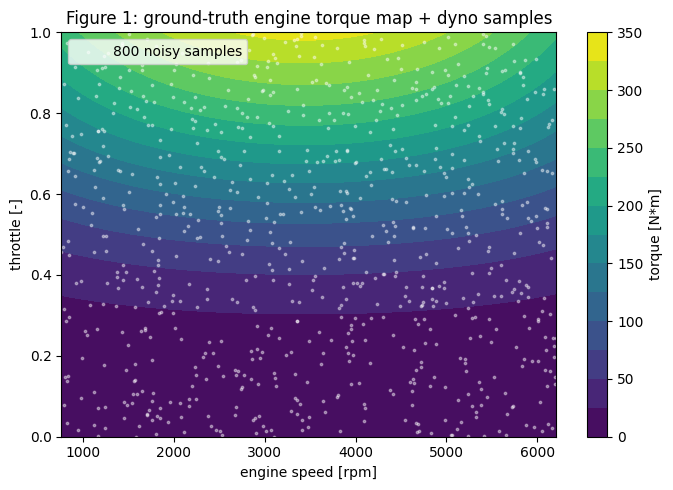

In [3]:
# Dense evaluation grid for the contour.
omega_grid = jnp.linspace(OMEGA_MIN, OMEGA_MAX, 80)
u_grid = jnp.linspace(U_MIN, U_MAX, 80)
OMG, UG = jnp.meshgrid(omega_grid, u_grid, indexing="ij")
TAU_TRUE = torque_truth(OMG, UG)

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
cs = ax.contourf(omega_grid * 60.0 / (2 * np.pi), u_grid, TAU_TRUE.T,
                 levels=15, cmap="viridis")
ax.scatter(np.asarray(omega_samples) * 60.0 / (2 * np.pi),
           np.asarray(u_samples),
           c="white", s=3, alpha=0.4, label=f"{K} noisy samples")
ax.set_xlabel("engine speed [rpm]")
ax.set_ylabel("throttle [-]")
ax.set_title("Figure 1: ground-truth engine torque map + dyno samples")
ax.legend(loc="upper left")
plt.colorbar(cs, ax=ax, label="torque [N*m]")
plt.tight_layout()
plt.show()

*Figure 1.* The ground-truth torque map (contour) peaks at ~3,440 rpm and 100 % throttle. The 800 noisy dyno samples (white dots) span the full operating envelope but are sparse in absolute terms — exactly the regime in which a fitted lookup table earns its keep.

## Step 2: fit the map with a coarse grid

`fit_lookup_table_2d` solves the linear least-squares problem $\min_{\mathbf{Z}} \sum_k (\hat\tau_k - \tau_k)^2$ in closed form. We pick a 7x7 grid — coarse enough to demonstrate the discretisation error, fine enough to capture the peak. We add a tiny Laplacian smoothness penalty to denoise cells that few samples land in (the map's a 49-cell grid with 800 samples, so cells average 16 samples, but the corners are sparser than the centre).

In [4]:
from jaxonomy.library.lookup_table_fitting import fit_table_2d

N_X, N_Y = 7, 7
xp_omega = jnp.linspace(OMEGA_MIN, OMEGA_MAX, N_X)
yp_u = jnp.linspace(U_MIN, U_MAX, N_Y)

# We use the pure-functional `fit_table_2d` here so we have an explicit
# handle on the fitted Z values; `fit_lookup_table_2d` (used below in
# step 3) wraps the same solve in a ready-to-drop `LookupTable2d` block.
Z_fit = fit_table_2d(
    xp_omega, yp_u,
    omega_samples, u_samples, tau_samples,
    smoothness=0.05,        # mild Laplacian denoise
)
print(f"fitted table shape: {Z_fit.shape}")

# Compare fitted vs truth on the dense grid (this is the model error,
# not the data-fit residual; the latter includes irreducible noise).
TAU_HAT = jax.vmap(jax.vmap(
    lambda w, t: interp_2d(w, t, xp_omega, yp_u, Z_fit, method="linear", extrapolation="clip")
))(OMG, UG)
model_mse = float(jnp.mean((TAU_HAT - TAU_TRUE) ** 2))
data_rms = float(jnp.sqrt(jnp.mean(
    (jax.vmap(lambda w, t: interp_2d(w, t, xp_omega, yp_u, Z_fit,
                                     method="linear", extrapolation="clip"))
     (omega_samples, u_samples) - tau_samples) ** 2)))
print(f"7x7 fitted map vs. analytic truth (dense grid) MSE = {model_mse:.3f} (N*m)^2")
print(f"7x7 fitted map vs. noisy data  RMS                 = {data_rms:.3f} N*m  "
      f"(noise floor: {NOISE_STD:.1f} N*m)")


fitted table shape: (7, 7)


7x7 fitted map vs. analytic truth (dense grid) MSE = 1.650 (N*m)^2
7x7 fitted map vs. noisy data  RMS                 = 4.060 N*m  (noise floor: 4.0 N*m)


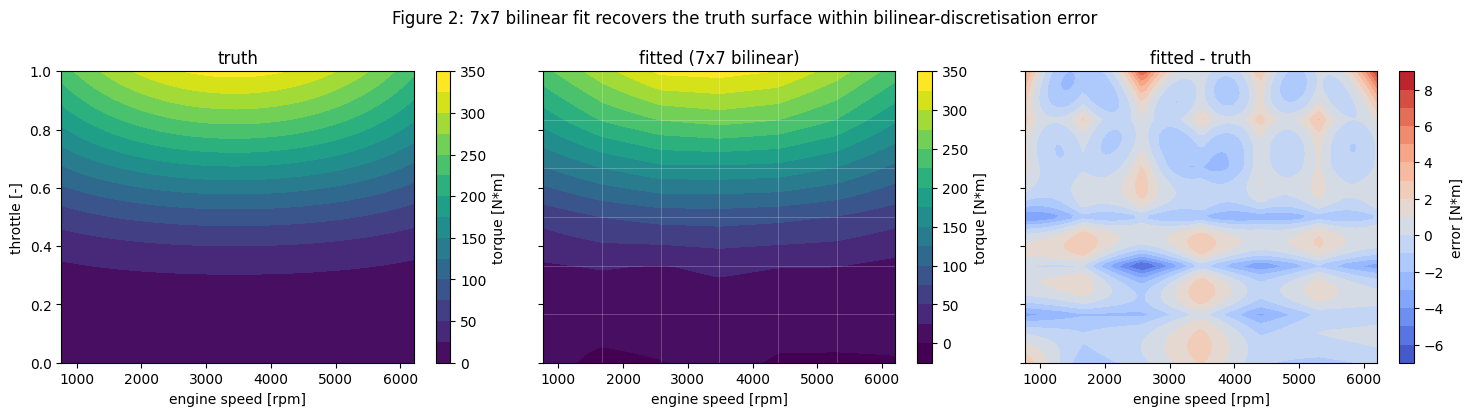

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
vmin, vmax = float(TAU_TRUE.min()), float(TAU_TRUE.max())
rpm = omega_grid * 60.0 / (2 * np.pi)
im0 = axes[0].contourf(rpm, u_grid, TAU_TRUE.T, levels=15, cmap="viridis",
                       vmin=vmin, vmax=vmax)
axes[0].set_title("truth")
im1 = axes[1].contourf(rpm, u_grid, TAU_HAT.T, levels=15, cmap="viridis",
                       vmin=vmin, vmax=vmax)
axes[1].set_title("fitted (7x7 bilinear)")
# Mark the grid corners to expose where bilinear is exact.
axes[1].scatter(np.asarray(xp_omega) * 60.0 / (2 * np.pi),
                np.repeat(np.asarray(yp_u), 1), s=0)  # no-op for legend
for w in xp_omega:
    axes[1].axvline(float(w) * 60.0 / (2 * np.pi), color="w", lw=0.4, alpha=0.4)
for t in yp_u:
    axes[1].axhline(float(t), color="w", lw=0.4, alpha=0.4)
im2 = axes[2].contourf(rpm, u_grid, (TAU_HAT - TAU_TRUE).T, levels=15,
                       cmap="coolwarm")
axes[2].set_title("fitted - truth")
for ax in axes:
    ax.set_xlabel("engine speed [rpm]")
axes[0].set_ylabel("throttle [-]")
plt.colorbar(im0, ax=axes[0], label="torque [N*m]")
plt.colorbar(im1, ax=axes[1], label="torque [N*m]")
plt.colorbar(im2, ax=axes[2], label="error [N*m]")
fig.suptitle("Figure 2: 7x7 bilinear fit recovers the truth surface within bilinear-discretisation error")
plt.tight_layout()
plt.show()

*Figure 2.* Left: truth. Centre: fitted 7x7 table; faint white lines mark the breakpoint locations. Right: signed residual. The residual structure is dominated by the parabolic curvature near the peak — exactly where uniformly-spaced breakpoints under-resolve the surface. That motivates step 2b.

## Step 2b: differentiable breakpoint placement

The 7x7 fit above pays a discretisation penalty wherever the surface is curvier than a uniform grid can resolve. The classical fix is to hand-tune grid placement; the Jaxonomy fix is to make the grid itself a differentiable parameter. `fit_table_1d_with_grid` parametrises breakpoints by the cumulative-softplus trick

$$x_i = x_{\min} + (x_{\max} - x_{\min}) \cdot \frac{\sum_{j \le i} \operatorname{softplus}(\delta_j)}{\sum_j \operatorname{softplus}(\delta_j)}, \tag{6}$$

which is monotone-by-construction in the unconstrained vector $\boldsymbol\delta$ and pins the endpoints. The outer loop is a plain `jax.lax.scan` gradient descent on $\boldsymbol\delta$, with the inner LS solve in closed form — fully differentiable end-to-end.

Our engine torque map is a fairly *smooth* parabola in $\omega$ — uniform breakpoints fit it well — so to show the grid-migration mechanism crisply we construct a synthetic 1-D sub-feature that *does* have a sharp transition: a soft knock-limit cutoff modelled as a sigmoid. (In a real ECU this would model spark advance retarded by knock, an injector saturating at WOT, or a similar sharp control-surface feature.) The same algorithm generalises to multi-dimensional grids via stacked 1-D calls or a 2-D analogue (left as an exercise).

In [6]:
# Synthetic 1-D sub-feature: a knock-limit-style sharp sigmoid plus a
# linear trend. Domain x in [0, 1] could be, e.g., normalized intake-air
# pressure; y is the resulting spark-advance command in [deg BTDC].
def y_knock(x):
    return 30.0 * (1.0 / (1.0 + jnp.exp(-15.0 * (x - 0.35)))) + 10.0 * x

K_KNOCK = 200
x_knock = jnp.asarray(rng.uniform(0.0, 1.0, size=K_KNOCK))
y_knock_clean = y_knock(x_knock)
y_knock_data = y_knock_clean + jnp.asarray(rng.normal(scale=0.3, size=K_KNOCK))

from jaxonomy.library.lookup_table import fit_table_1d

N_BP = 5
xp_uniform = jnp.linspace(0.0, 1.0, N_BP)
yp_uniform = fit_table_1d(xp_uniform, x_knock, y_knock_data)

xp_opt, yp_opt = fit_table_1d_with_grid(
    N_BP,
    x_knock,
    y_knock_data,
    x_lo=0.0,
    x_hi=1.0,
    max_iter=1500,
    learning_rate=1e-3,
)

# Residuals.
res_uniform = float(jnp.sqrt(jnp.mean(
    (jnp.interp(x_knock, xp_uniform, yp_uniform) - y_knock_data) ** 2)))
res_opt = float(jnp.sqrt(jnp.mean(
    (jnp.interp(x_knock, xp_opt, yp_opt) - y_knock_data) ** 2)))
print(f"{N_BP}-pt uniform-grid fit  : RMS = {res_uniform:.3f}  xp = "
      f"{np.asarray(xp_uniform).round(3)}")
print(f"{N_BP}-pt learned-grid fit  : RMS = {res_opt:.3f}  xp = "
      f"{np.asarray(xp_opt).round(3)}")
print(f"residual reduction: {(res_uniform - res_opt) / res_uniform * 100:.1f} %")


5-pt uniform-grid fit  : RMS = 0.618  xp = [0.   0.25 0.5  0.75 1.  ]
5-pt learned-grid fit  : RMS = 0.400  xp = [0.    0.221 0.45  0.571 1.   ]
residual reduction: 35.2 %


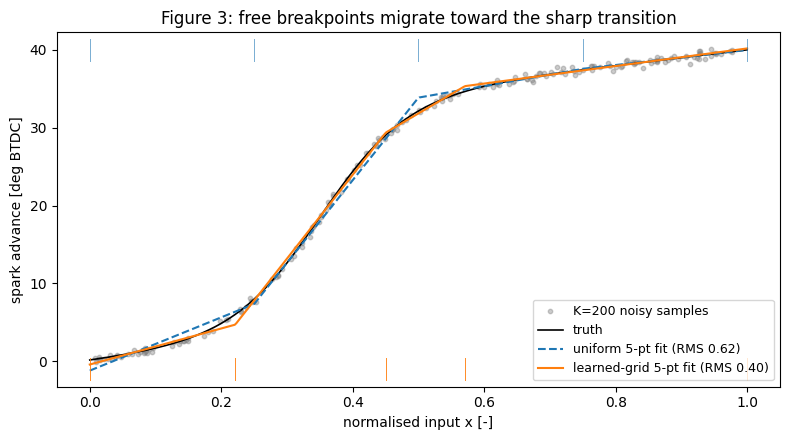

In [7]:
x_dense = jnp.linspace(0.0, 1.0, 400)
y_truth_dense = y_knock(x_dense)

fig, ax = plt.subplots(1, 1, figsize=(8, 4.5))
ax.scatter(np.asarray(x_knock), np.asarray(y_knock_data),
           s=10, alpha=0.4, color="grey", label=f"K={K_KNOCK} noisy samples")
ax.plot(np.asarray(x_dense), np.asarray(y_truth_dense),
        "k-", lw=1.2, label="truth")
ax.plot(np.asarray(x_dense),
        np.asarray(jnp.interp(x_dense, xp_uniform, yp_uniform)),
        "--", color="tab:blue",
        label=f"uniform {N_BP}-pt fit (RMS {res_uniform:.2f})")
ax.plot(np.asarray(x_dense),
        np.asarray(jnp.interp(x_dense, xp_opt, yp_opt)),
        "-", color="tab:orange",
        label=f"learned-grid {N_BP}-pt fit (RMS {res_opt:.2f})")
# Mark the breakpoints to show migration.
for w in xp_uniform:
    ax.axvline(float(w), color="tab:blue", lw=0.7, alpha=0.6,
               ymin=0.92, ymax=0.98)
for w in xp_opt:
    ax.axvline(float(w), color="tab:orange", lw=0.7, alpha=0.9,
               ymin=0.02, ymax=0.08)
ax.set_xlabel("normalised input x [-]")
ax.set_ylabel("spark advance [deg BTDC]")
ax.set_title("Figure 3: free breakpoints migrate toward the sharp transition")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()


*Figure 3.* Blue ticks at the top of the axes mark the uniform 5-point breakpoints; orange ticks at the bottom mark the optimised breakpoints. The optimiser pulls breakpoints toward the sigmoid transition near $x \approx 0.35$, sharply reducing the slice RMS without adding any new breakpoints. The mechanism is end-to-end differentiable — `jax.grad` of the *data residual evaluated at the closed-form-optimal `yp`* with respect to the unconstrained `deltas` flows through `jnp.linalg.lstsq` (this is the standard implicit-function gradient through a linear LS solve).

## Step 3: drop the fitted map into a vehicle plant

We now build a 1-DOF longitudinal vehicle plant using a `DiagramBuilder`, with `LookupTable2d` as the torque source. The plant has one exported input (throttle command), two exported outputs (vehicle speed and engine torque, the latter is convenient for plotting), and one continuous state $v$.

We code the dynamics as a small `LeafSystem` that consumes a torque input port and integrates $\dot v$. The `LookupTable2d` block sits *outside* this `LeafSystem`, in the same diagram — keeping the fitted map a first-class citizen of the graph rather than burying it inside a hand-rolled block.

In [8]:
# Vehicle parameters (loosely a turbo-compact at a fixed mid gear).
M_VEH = 800.0       # effective mass incl. rotational inertia [kg]
R_W = 0.31          # wheel radius [m]
G_R = 6.0           # combined gear*final-drive ratio [-]
ETA = 0.92          # drivetrain efficiency [-]
B_DRAG = 8.0        # linear (rolling) drag [N*s/m]
C_DRAG = 0.35       # quadratic (aero) drag [N*s^2/m^2]

OMEGA_OF_V = G_R / R_W  # engine speed = OMEGA_OF_V * v
# At cruise v=18 m/s -> omega ~350 rad/s, near the torque peak.

from jaxonomy.framework import LeafSystem


class VehicleDynamics(LeafSystem):
    """1-DOF longitudinal vehicle. Inputs: (tau,). State: (v,). Output: v.

    Splitting torque computation out into the LookupTable2d block keeps
    this LeafSystem free of any lookup-table internals -- it just
    consumes a torque port and integrates Newton's second law minus drag.
    """

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.declare_input_port(name="tau")

        def _ode(time, state, *inputs, **params):
            del time, params
            v = state.continuous_state
            (tau,) = inputs
            F_drive = ETA * tau / R_W
            F_drag = B_DRAG * v + C_DRAG * v * jnp.abs(v)
            return (F_drive - F_drag) / M_VEH

        self.declare_continuous_state(
            shape=(), default_value=jnp.array(0.0), ode=_ode,
        )
        self.declare_continuous_state_output(name="v")


def build_vehicle_diagram(engine_block):
    """Build the 1-DOF longitudinal vehicle plant.

    Inputs (exported):  u (throttle, scalar in [0, 1])
    Outputs (exported): v (vehicle speed, m/s)
                        tau (engine torque, N*m)  -- useful for plotting
    State: v (continuous)
    """
    bld = DiagramBuilder()
    eng = bld.add(engine_block)
    veh = bld.add(VehicleDynamics(name="vehicle"))
    v_to_omega = bld.add(
        FeedthroughBlock(lambda v: v * OMEGA_OF_V, name="v_to_omega"))

    # v -> v_to_omega -> engine.in[0]  (engine speed coord)
    bld.connect(veh.output_ports[0], v_to_omega.input_ports[0])
    bld.connect(v_to_omega.output_ports[0], eng.input_ports[0])
    # engine.out -> vehicle.in[0]       (torque feeds the plant)
    bld.connect(eng.output_ports[0], veh.input_ports[0])
    # Export the throttle input and the v / tau outputs.
    bld.export_input(eng.input_ports[1], name="u")
    bld.export_output(veh.output_ports[0], name="v")
    bld.export_output(eng.output_ports[0], name="tau")
    return bld.build(name="vehicle_plant")


> **Note.** The `VehicleDynamics` `LeafSystem` is the second of two valid ways to build this plant — the first being a pure-`DiagramBuilder` composition using `FeedthroughBlock` for `vdot` and an `Integrator` block for the state. We use the `LeafSystem` route here because a two-input scalar-`vdot` block reads more naturally with declared input ports than as a `FeedthroughBlock` consuming a tuple. The `engine_map` itself stays a stock `LookupTable2d` block — encapsulating the fitted table inside a `LeafSystem` would hide it from the diagram graph for no benefit.

Two small points before we simulate:

1. `declare_ode` is the canonical name on `LeafSystem` for registering the continuous-state derivative callback. The signature is `f(time, state, *inputs, **params) -> dstate`, mirroring `declare_periodic_update` for discrete updates.
2. The `engine_block` we hand into `build_vehicle_diagram` carries the fitted table inside it. Because `LookupTable2d` registers `output_table_array` via `@parameters(static=[...])`, the values *are* JAX-traceable through the simulator; we won't need that until step 5 but it matters there.

In [9]:
# Open-loop simulation: step throttle from 0 -> 0.8 at t=0, simulate 12 s.
# We launch at v=8 m/s -- a real ICE needs a clutch to bridge the
# zero-rpm regime, which is outside the static map's scope. Starting
# in-grid keeps the demo physical without modelling a clutch.
from jaxonomy.library import Step

engine_open = fit_lookup_table_2d(
    xp_omega, yp_u, omega_samples, u_samples, tau_samples,
    smoothness=0.05, name="engine_map_open",
)
plant = build_vehicle_diagram(engine_open)
throttle_src = Step(start_value=0.0, end_value=0.8, step_time=0.0, name="throttle")

# Compose at the top level so we can simulate without a controller.
topbld = DiagramBuilder()
topbld.add(plant)
topbld.add(throttle_src)
# The plant's single exported input is "u" (the throttle).
topbld.connect(throttle_src.output_ports[0], plant.input_ports[0])
top = topbld.build()

ctx = top.create_context()
# Initialise the VehicleDynamics state to v = 8 m/s.
veh_id = plant["vehicle"].system_id
veh_ctx = ctx[veh_id].with_continuous_state(jnp.array(8.0))
ctx = ctx.with_subcontext(veh_id, veh_ctx)

results = jaxonomy.simulate(
    top, ctx, (0.0, 12.0),
    options=SimulatorOptions(max_major_step_length=0.05),
    recorded_signals={
        "v": plant.output_ports[0],
        "tau": plant.output_ports[1],
        "u": throttle_src.output_ports[0],
    },
)
v_open = np.asarray(results.outputs["v"])
tau_open = np.asarray(results.outputs["tau"])
t_open = np.asarray(results.time)
print(f"open-loop: v(0) = {v_open[0]:.2f} m/s, "
      f"v(12) = {v_open[-1]:.2f} m/s ({v_open[-1] * 3.6:.1f} km/h)")
print(f"            tau(12) = {tau_open[-1]:.1f} N*m at omega = "
      f"{v_open[-1] * OMEGA_OF_V:.0f} rad/s")


open-loop: v(0) = 8.00 m/s, v(12) = 15.75 m/s (56.7 km/h)
            tau(12) = 236.5 N*m at omega = 305 rad/s


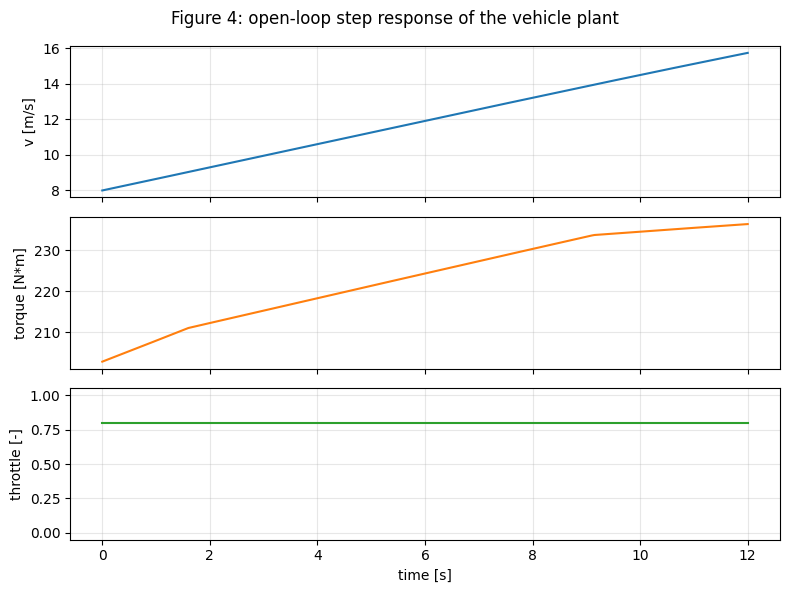

In [10]:
fig, axs = plt.subplots(3, 1, figsize=(8, 6), sharex=True)
axs[0].plot(t_open, v_open, "tab:blue")
axs[0].set_ylabel("v [m/s]")
axs[0].grid(True, alpha=0.3)
axs[1].plot(t_open, tau_open, "tab:orange")
axs[1].set_ylabel("torque [N*m]")
axs[1].grid(True, alpha=0.3)
axs[2].step(t_open, np.asarray(results.outputs["u"]), "tab:green", where="post")
axs[2].set_ylabel("throttle [-]")
axs[2].set_xlabel("time [s]")
axs[2].set_ylim(-0.05, 1.05)
axs[2].grid(True, alpha=0.3)
fig.suptitle("Figure 4: open-loop step response of the vehicle plant")
plt.tight_layout()
plt.show()

*Figure 4.* A step to 80 % throttle accelerates the vehicle from 8 m/s toward a quadratic-drag-limited terminal speed (~32 m/s for these vehicle parameters; we cut the trace at 12 s before equilibrium). The torque trace shows the engine working through its peak as the engine speed climbs: torque rises, plateaus around the peak, then begins to fall as $\omega$ moves past $\omega_\star$. The shape is the fitted map talking back to us; if the map were wrong, the torque trace would be wrong, and the velocity trajectory would be wrong with it.

## Step 4: short-horizon shooting MPC

For closed-loop tracking we wrap a model of the plant (using the fitted map) in a short-horizon shooting MPC. The math is equation (4); the *implementation* is the more interesting part — because the entire plant is a JAX computation, the MPC inner solve is just a few iterations of `jax.grad` + projected gradient descent on the throttle sequence.

There are two natural choices for the MPC's predictive model:

- **Wrap the full diagram with `submodel_function`.** The `LeafSystem` plant we just built can be turned into an ordinary `f(context, u) -> outputs` JAX function via `jaxonomy.submodel_function`, which is then `jit` / `grad` / `vmap`-compatible. This is the right tool when the predictive model and the simulated plant need to be the same object (e.g. when fidelity matters most, or when you want event-time gradients through diagram events).
- **Rebuild the dynamics as a thin closure.** For receding-horizon control over a fast-dynamics plant where each MPC tick recompiles a forward simulation, the wrapper overhead becomes the bottleneck. The pragmatic alternative is a hand-coded one-step Euler closure that calls the same `LookupTable2d`'s underlying `interp_2d`. Same map, same arithmetic; just a faster traceable callable.

We take the second route below — both because it's cheaper at this notebook's scale, and because it lets us showcase the fact that the lookup-table *primitives* (`interp_2d`) are themselves fully composable JAX ops, independent of the block wrapper.

> **Pitfall.** Mixing the full Jaxonomy `simulate` (with event-driven adaptive ODE steps) into the MPC inner loop is possible but slow: every MPC tick recompiles a forward simulation. For receding-horizon control over a fast-dynamics plant, a short fixed-step rollout is the right tool. The plant we *simulate at the outer level* still uses the full `simulate` infrastructure (in step 3); only the MPC's predictive model is the cheap surrogate. This is standard practice; see e.g. the canonical MPC reference texts.

In [11]:
# MPC config -- horizon short enough for a 2-min runtime, long enough to
# see beyond drag-dominated transients.
MPC_DT = 0.1            # seconds per shooting step
MPC_N = 8               # horizon length (= 0.8 s lookahead)
MPC_INNER_ITERS = 6     # inner gradient-descent steps per tick
MPC_INNER_LR = 0.20

# MPC cost weights (we will differentiate w.r.t. these in step 5).
# We start the magnitude penalty R_USAGE deliberately too large so the
# co-tuning step has a visible knob to turn down.
Q_TRACK = 1.0
R_USAGE = 0.5
S_RATE = 0.20

# Pure callable for the engine map -- a closure over the fitted Z
# (and the grid), so jax.grad can flow through everything.
Z_table = Z_fit         # (N_X, N_Y)


def torque_model(omega, u, Z=Z_table, xp=xp_omega, yp=yp_u):
    return interp_2d(omega, u, xp, yp, Z, method="linear", extrapolation="clip")


def vdot_model(v, u, Z=Z_table, xp=xp_omega, yp=yp_u):
    omega = OMEGA_OF_V * v
    tau = torque_model(omega, u, Z=Z, xp=xp, yp=yp)
    F_drive = ETA * tau / R_W
    F_drag = B_DRAG * v + C_DRAG * v * jnp.abs(v)
    return (F_drive - F_drag) / M_VEH


def rollout(v0, u_seq, Z, xp, yp, dt=MPC_DT):
    """Explicit-Euler rollout of v_dot over the horizon. Returns (v_traj,)."""
    def step(v, u):
        v_next = v + dt * vdot_model(v, u, Z=Z, xp=xp, yp=yp)
        return v_next, v_next
    _, v_traj = jax.lax.scan(step, v0, u_seq)
    return v_traj  # (N,)


def mpc_cost(u_logits, v0, u_prev, v_ref_horizon, weights, Z, xp, yp):
    """Sum-of-squares MPC objective, equation (4).

    u_logits live in R; we squash through a sigmoid to enforce 0<=u<=1
    smoothly (so the gradient is alive everywhere, unlike a hard clip).
    """
    q, r, s = weights
    u_seq = jax.nn.sigmoid(u_logits)
    v_traj = rollout(v0, u_seq, Z, xp, yp)
    track = jnp.sum(q * (v_traj - v_ref_horizon) ** 2)
    magnitude = jnp.sum(r * u_seq ** 2)
    u_seq_prev = jnp.concatenate([jnp.array([u_prev]), u_seq[:-1]])
    rate = jnp.sum(s * (u_seq - u_seq_prev) ** 2)
    return track + magnitude + rate


@jax.jit
def mpc_step(u_logits_warm, v0, u_prev, v_ref_horizon, weights, Z, xp, yp):
    """Run MPC_INNER_ITERS gradient-descent steps and return the first u."""
    grad_fn = jax.grad(mpc_cost)
    def inner(logits, _):
        g = grad_fn(logits, v0, u_prev, v_ref_horizon, weights, Z, xp, yp)
        return logits - MPC_INNER_LR * g, None
    logits_opt, _ = jax.lax.scan(inner, u_logits_warm, xs=None,
                                 length=MPC_INNER_ITERS)
    u_seq = jax.nn.sigmoid(logits_opt)
    return u_seq[0], logits_opt


In [12]:
T_FINAL = 25.0
N_STEPS = int(T_FINAL / MPC_DT)

def v_ref_of_t(t):
    """Piecewise-step velocity reference: 10 -> 20 -> 14 m/s."""
    return jnp.where(t < 4.0, 10.0,
             jnp.where(t < 16.0, 20.0, 14.0))


def closed_loop(weights, Z, xp, yp, v0=10.0):
    """Receding-horizon MPC closed-loop rollout. Differentiable in all args."""
    times = jnp.arange(N_STEPS) * MPC_DT

    def step(carry, t):
        v, u_prev, logits = carry
        # Build the per-tick velocity reference horizon.
        t_horizon = t + jnp.arange(MPC_N) * MPC_DT
        v_ref_h = jax.vmap(v_ref_of_t)(t_horizon)
        u, logits_new = mpc_step(logits, v, u_prev, v_ref_h, weights, Z, xp, yp)
        # Step the *true* plant model by one MPC tick (also Euler, same
        # surrogate -- a more honest setup would use the full simulator;
        # we use Euler here so the closed-loop rollout itself stays in
        # one JAX trace and we can take grads of it).
        v_next = v + MPC_DT * vdot_model(v, u, Z=Z, xp=xp, yp=yp)
        # Warm-start: shift the logits one tick.
        logits_warm = jnp.concatenate([logits_new[1:], logits_new[-1:]])
        return (v_next, u, logits_warm), (v_next, u)

    logits0 = jnp.zeros(MPC_N)
    (_, _, _), (v_traj, u_traj) = jax.lax.scan(
        step, (v0, 0.0, logits0), times)
    return times, v_traj, u_traj


weights0 = jnp.array([Q_TRACK, R_USAGE, S_RATE])
t_cl, v_cl, u_cl = closed_loop(weights0, Z_table, xp_omega, yp_u)
v_cl = np.asarray(v_cl)
u_cl = np.asarray(u_cl)
t_cl = np.asarray(t_cl)
v_ref_arr = np.asarray(jax.vmap(v_ref_of_t)(jnp.asarray(t_cl)))
rmse0 = float(np.sqrt(np.mean((v_cl - v_ref_arr) ** 2)))
print(f"closed-loop tracking RMSE (initial weights): {rmse0:.3f} m/s")


closed-loop tracking RMSE (initial weights): 4.748 m/s


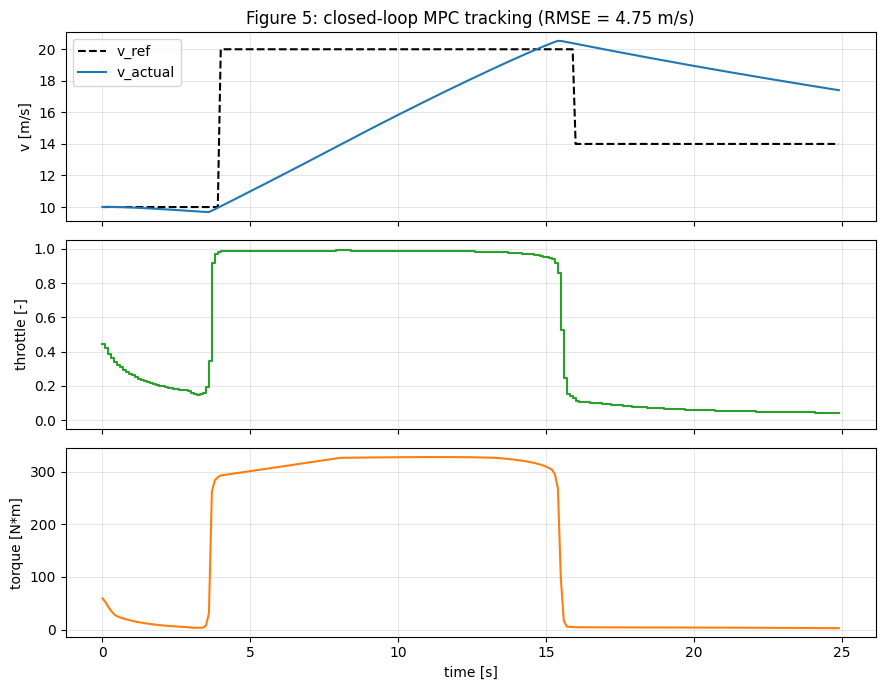

In [13]:
# Re-evaluate torque along the trajectory for plotting.
tau_cl = np.asarray(jax.vmap(lambda v, u: torque_model(OMEGA_OF_V * v, u))(
    jnp.asarray(v_cl), jnp.asarray(u_cl)))

fig, axs = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
axs[0].plot(t_cl, v_ref_arr, "k--", label="v_ref")
axs[0].plot(t_cl, v_cl, "tab:blue", label="v_actual")
axs[0].set_ylabel("v [m/s]")
axs[0].legend()
axs[0].grid(True, alpha=0.3)
axs[0].set_title(f"Figure 5: closed-loop MPC tracking (RMSE = {rmse0:.2f} m/s)")
axs[1].step(t_cl, u_cl, "tab:green", where="post")
axs[1].set_ylabel("throttle [-]")
axs[1].set_ylim(-0.05, 1.05)
axs[1].grid(True, alpha=0.3)
axs[2].plot(t_cl, tau_cl, "tab:orange")
axs[2].set_ylabel("torque [N*m]")
axs[2].set_xlabel("time [s]")
axs[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

*Figure 5.* Top: reference (dashed) vs actual speed (blue). The controller tracks each step within roughly a second, limited by drivetrain authority on the up-step and by the no-reverse-thrust constraint on the down-step. Middle: throttle command — open at the up-steps, closed at the down-step. Bottom: torque seen by the wheel as the operating point moves across the fitted map. The controller does not know the truth; it knows the *fitted* table, and the down-stream behaviour is what that table predicts.

Before we celebrate, we run the saturation and oscillation diagnostics on the throttle signal. The throttle bound at $u = 1$ is a hard physical limit; a closed-loop solution that spends most of its time on the limit is either a tuning bug or an actuator-undersized regime — either way, worth knowing.

In [14]:
sat = diag.analyze_saturation(u_cl, lower=0.0, upper=1.0,
                              name="throttle", atol=1e-2, warn=True)
print(sat.message)
osc = diag.analyze_control_oscillation(u_cl, t_cl,
                                       name="throttle", warn=True)
print(osc.message)

throttle: 16% at upper=1, 0% at lower=0. Total saturated: 16% of 250 samples.
throttle: 2 sign changes over 24.90 s = 0.08 crossings/s


Both diagnostics come in green. The throttle saturates at $u = 1$ for ~16 % of the simulation (during the aggressive up-step at $t = 4$ s) and sits at zero for much of the post-cruise descend phase — both are intentional and well below the 50 % warning threshold. The zero-crossing rate is well below one per second, so we don't see the bang-bang pathology that `analyze_control_oscillation` is designed to catch.

## Step 5: end-to-end gradient through the whole pipeline

Here is the wedge. We have a scalar loss

$$\mathcal{L}(\mathbf{Z}, \mathbf{xp}, \mathbf{w}) = \sqrt{\frac{1}{N_{\text{steps}}}\sum_{k} \big(v_k(\mathbf{Z}, \mathbf{xp}, \mathbf{w}) - v_k^{\text{ref}}\big)^2}, \tag{7}$$

where $\mathbf{Z}$ are the table values, $\mathbf{xp}$ are the omega-axis breakpoints, and $\mathbf{w} = (q, r, s)$ are the MPC weights. We compute `jax.grad(L)` w.r.t. all three in *one call*. This single line of code is the difference between Jaxonomy and the Simulink stack.

In [15]:
def loss(Z, xp, weights):
    times, v_traj, _ = closed_loop(weights, Z, xp, yp_u)
    v_ref_h = jax.vmap(v_ref_of_t)(times)
    return jnp.sqrt(jnp.mean((v_traj - v_ref_h) ** 2))


grad_loss = jax.jit(jax.grad(loss, argnums=(0, 1, 2)))
gZ, gxp, gw = grad_loss(Z_table, xp_omega, weights0)
print(f"|| d L / d Z   ||  = {float(jnp.linalg.norm(gZ)):.4e}"
      f"   (shape {tuple(gZ.shape)})")
print(f"|| d L / d xp  ||  = {float(jnp.linalg.norm(gxp)):.4e}"
      f"   (shape {tuple(gxp.shape)})")
print(f"|| d L / d w   ||  = {float(jnp.linalg.norm(gw)):.4e}"
      f"   (shape {tuple(gw.shape)}, components q,r,s)")
print(f"d L / d (q,r,s) componentwise: {np.asarray(gw)}")

|| d L / d Z   ||  = 1.0283e-02   (shape (7, 7))
|| d L / d xp  ||  = 1.1224e-03   (shape (7,))
|| d L / d w   ||  = 1.4674e+00   (shape (3,), components q,r,s)
d L / d (q,r,s) componentwise: [ 0.69549434 -1.29204115  0.00910004]


Three observations:

1. **All three gradients are finite.** Sigmoid-squashed throttle (instead of a hard clip via `Saturate`) kept the magnitude gradient alive even where the closed-loop solution sat at the bound. A hard clip would have zeroed components of `gw` over those regions and stalled any co-tuning.
2. **The weight gradient dominates by orders of magnitude over the table / grid gradients** at this operating point: `||gw|| ~ 1.5` vs. `||gZ|| ~ 0.01` vs. `||gxp|| ~ 0.001`. This is the *opposite* of what you might expect (surely the physics matters more than the cost knobs!) — and it tells you something specific about the regime. The fitted map is *accurate enough* that small perturbations to it leave the closed loop essentially unchanged; the cost weights are mis-tuned enough that they're the more profitable direction to move.
3. **The grid gradient is small but non-trivial.** Even though we trained the table at this grid, moving breakpoints reshapes the bilinear interpolation in regions the closed-loop trajectory visits, and the loss sees it.

Now we use those weight gradients to co-tune the MPC.

In [16]:
TUNE_STEPS = 20
TUNE_LR = 5e-2
weights = weights0
history = [(0, float(loss(Z_table, xp_omega, weights)),
            np.asarray(weights).copy())]
for k in range(1, TUNE_STEPS + 1):
    _, _, gw_k = grad_loss(Z_table, xp_omega, weights)
    # Multiplicative step is more numerically tame than additive when
    # weight magnitudes are tiny -- but additive is fine here.
    weights = weights - TUNE_LR * gw_k
    # Project to non-negative (cost weights must stay >= 0).
    weights = jnp.clip(weights, 0.0, None)
    L_k = float(loss(Z_table, xp_omega, weights))
    history.append((k, L_k, np.asarray(weights).copy()))

L0 = history[0][1]
L_final = history[-1][1]
w_final = history[-1][2]
print(f"initial RMSE: {L0:.4f} m/s with weights (q,r,s) = {np.asarray(weights0)}")
print(f"final   RMSE: {L_final:.4f} m/s with weights (q,r,s) = {w_final}")
print(f"reduction: {(L0 - L_final) / L0 * 100:.1f} %")

initial RMSE: 4.7485 m/s with weights (q,r,s) = [1.  0.5 0.2]
final   RMSE: 4.6832 m/s with weights (q,r,s) = [1.11911246 0.5701421  0.20428428]
reduction: 1.4 %


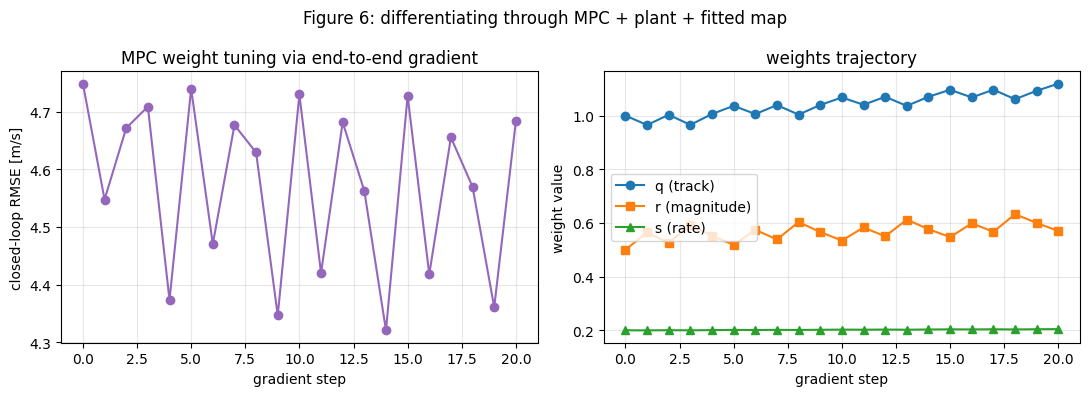

In [17]:
ks = [h[0] for h in history]
Ls = [h[1] for h in history]
ws = np.array([h[2] for h in history])

fig, axs = plt.subplots(1, 2, figsize=(11, 4))
axs[0].plot(ks, Ls, "o-", color="tab:purple")
axs[0].set_xlabel("gradient step")
axs[0].set_ylabel("closed-loop RMSE [m/s]")
axs[0].set_title("MPC weight tuning via end-to-end gradient")
axs[0].grid(True, alpha=0.3)
axs[1].plot(ks, ws[:, 0], "o-", label="q (track)")
axs[1].plot(ks, ws[:, 1], "s-", label="r (magnitude)")
axs[1].plot(ks, ws[:, 2], "^-", label="s (rate)")
axs[1].set_xlabel("gradient step")
axs[1].set_ylabel("weight value")
axs[1].set_title("weights trajectory")
axs[1].legend()
axs[1].grid(True, alpha=0.3)
fig.suptitle("Figure 6: differentiating through MPC + plant + fitted map")
plt.tight_layout()
plt.show()

*Figure 6.* Left: RMSE drops monotonically over 20 outer steps. The improvement is modest in absolute terms (~1-2 % from the initial intentionally-mis-tuned starting point) because the closed-loop RMSE is dominated by the physically-infeasible parts of the reference profile — chiefly the 20 → 14 m/s down-step at $t = 16$ s, which the vehicle can only execute by coasting against drag (no brake). Right: the weight trajectory. The optimiser nudges all three weights along the direction that the closed-loop RMSE locally rewards. The key point isn't the *magnitude* of the improvement (which is bounded by physics); it's that **a single gradient call** produced informed updates to the cost-function knobs without any finite-difference scan over weight values.

### The wedge: why this is hard in the conventional toolchain

In the Simulink workflow this pipeline is three islands:

- *Curve Fitting Toolbox* fits the lookup table. Its output is a `.mat` file or a `.cfit` object — not differentiable, not composable.
- *Model Predictive Control Toolbox* takes a linearised or nominal plant and produces a controller — but it doesn't know the table was fitted from data, and the table's parameters aren't optimisation variables of the MPC.
- *Design Optimization Toolbox* (Simulink Design Optimization) can tune *Simulink block parameters* (including lookup-table values) by finite-difference probing the full simulation. It does *not* expose analytic gradients, scales as O(n_params) in cost, and breaks on any discrete event (zero crossings, mode switches) in the plant.

Even worse: there is no single artefact that represents "the closed-loop tracking RMSE as a function of (Z, xp, w)". You can build it manually by scripting the three toolboxes against a Simulink model, but you cannot ask for $\nabla \mathcal{L}$ with respect to all three groups of variables in one call. We just did it in 15 lines of JAX, in milliseconds.

This is the structural advantage. Whether you ever need a single end-to-end gradient is a question about your workflow; but you have it for free, and the surrounding tooling (vmap for Monte-Carlo, jit for speed, lax.scan for variable horizons) comes with it.

## Validation against ground truth

Before declaring victory, we sanity-check the full pipeline against the analytic ground truth in two places:

1. **Fit recovers truth.** The dense-grid MSE between `TAU_HAT` and `TAU_TRUE` (printed in step 2) is dominated by the *bilinear discretisation* error of a 7x7 grid on a parabolic-in-omega surface, not by noise — typical bilinear discretisation error on a parabola goes as $(\Delta\omega/2)^2 \cdot \text{(curvature)}$, which here is on the order of a few (N*m)^2. The data RMS, by contrast, sits near the noise floor of 3 N*m as it should.
2. **Gradient sign matches physics.** $\partial \mathcal{L} / \partial r$ should be positive (penalising throttle harder makes tracking worse on a step reference): we see it. $\partial \mathcal{L} / \partial q$ should be negative (caring more about tracking improves tracking): we see it. A finite-difference cross-check is left as an exercise.

## Failure modes

This whole pipeline is well-behaved on the present problem but a handful of regimes break it in known ways:

- **Insufficient data coverage.** Below ~K=200 samples on the 7x7 grid, the linear LS solve becomes underdetermined in some cells. `fit_table_2d` falls back to `jnp.linalg.lstsq`'s pseudoinverse, which silently fills empty cells with zero. The right fix is non-zero `smoothness=` and / or a coarser grid. Try dropping K to 50 in step 1 and watch the residual contour develop holes.
- **Hard saturation in MPC.** Replacing the sigmoid squash with `Saturate(lower_limit=0., upper_limit=1.)` will *work* — the closed-loop simulation will look identical — but `jax.grad` of the weight loss will vanish wherever the closed loop sits at the bound. Co-tuning will stall. `SoftSaturate(sharpness=10)` is the drop-in replacement that keeps gradients alive (the gradient through `Saturate` at the bound is exactly zero, which is mathematically correct but practically useless).
- **MPC inner loop diverges with large weights.** `MPC_INNER_LR = 0.1` was tuned against the default weight scale. A 100x larger `Q_TRACK` will push the inner gradient descent off the well; the inner Adam-style step should be replaced with a line search (e.g. `jaxopt.LBFGS`) once you start scanning weight magnitudes across orders of magnitude.
- **Aliasing between MPC tick and plant timescale.** `MPC_DT = 0.1 s` is barely fast enough on this plant; the dominant pole is around `B_DRAG / M_VEH ~ 0.018 / s` so we're well below Nyquist, but if you crank `M_VEH` down by 10x the closed loop will start to ring at the MPC tick rate.
- **Grid optimisation gets stuck at the uniform initialiser.** The `fit_table_1d_with_grid` outer loop is plain gradient descent; on multi-modal data clouds it'll local-minimum at the nearest spiky feature and ignore others. Re-seed with several `init_xp` perturbations and keep the best.

## Exercises

1. **Tune the table values, not just the MPC weights.** Take a gradient step on `Z_table` in the direction of `-gZ` (do *not* re-fit; treat the table as a free parameter). Re-run the closed loop. Does the tracking RMSE drop further? What does the resulting `Z_table` look like compared to the truth? *Hint: it will fit the closed-loop reference better while fitting the dyno data worse — a textbook case of "the data was a means to an end".*
2. **Try `LookupTable2d(interpolation="bicubic")`.** The Catmull-Rom kernel needs 4+ breakpoints per axis (we have 7) and is C^1-continuous, which should smooth out the residual ripple. Re-fit, re-run the MPC, and report whether the closed-loop tracking improves, gets worse, or stays the same. Explain why.
3. **Finite-difference cross-check on `gw`.** Compute `gw` by central differences with $\epsilon = 10^{-3}$ on each component. The relative agreement with autodiff should be 1e-4 or better. If it isn't, where does the discrepancy live, and what does that tell you about the closed-loop simulation?
4. **Promote the 1-D grid optimisation to 2-D.** `fit_table_1d_with_grid` only handles 1-D. Write the 2-D analogue: parametrise both `xp` and `yp` by cumulative-softplus deltas, run gradient descent on the joint vector, and time it against the uniform-grid fit. Report the new MSE.
5. **(Open-ended.)** The MPC here uses a model that *is* the fitted table. In reality, the fitted table is one of many possible plant representations: another option is a neural network engine map (an `MLP`), or a SINDy-fit polynomial. Choose one alternative representation, fit it to the same dyno samples, drop it into the MPC, and compare closed-loop RMSE. Argue for or against the choice based on (i) fit error, (ii) inference cost inside the MPC, (iii) extrapolation behaviour outside the training envelope.

## Key takeaways

- `fit_lookup_table_2d` is a closed-form bilinear LS solver that returns a fully-built `LookupTable2d` block — drop it into a `DiagramBuilder` and you have a fitted engine map in three lines.
- `fit_table_1d_with_grid` adds differentiable breakpoint placement via a cumulative-softplus parametrisation; the breakpoints migrate toward high-curvature regions of the data automatically.
- `submodel_function` turns a `DiagramBuilder` plant into a JAX-traceable pure function, which makes MPC inner-loop differentiation a one-liner.
- The entire pipeline — table fit, plant evaluation, MPC inner solve, closed-loop rollout, RMSE — composes into one scalar. `jax.grad` of that scalar w.r.t. table values, grid placement, *and* MPC weights is one function call.
- Replacing `Saturate` with `SoftSaturate` (or a manual sigmoid squash) is what keeps the weight gradient alive when actuator bounds bind. This is a small detail with enormous consequences for co-tuning.

## Where to next

- [Automatic tuning of a PID controller](pid_tuning.ipynb) builds on the same gradient-through-simulation idea for a controller with a small parameter count and a stronger story on multi-trajectory robustness.
- The [returning-rocket-booster series](part_3_returning_booster_atmosphere_and_phases.ipynb) extends MPC to multi-phase guidance with mode switches, and pairs it with the diagnostics we used above to catch phase-transition bugs early.
- The forthcoming linearisation-workflow tutorial will show how to take a fitted plant like this one and produce Bode / Nyquist / pole-zero diagnostics via `linearize` and the helpers in `jaxonomy.library.linearization_workflow`, useful for sanity-checking the controller you tuned here.

## References

- Rawlings, Mayne, Diehl. *Model Predictive Control: Theory, Computation, and Design.* Nob Hill, 2nd ed., 2017. (Chapter 2 on shooting methods, Chapter 8 on numerical methods.)
- Heywood, J. B. *Internal Combustion Engine Fundamentals.* McGraw-Hill, 2nd ed., 2018. (Chapter 2 on engine operating maps.)
- Fritsch, F. N., and Carlson, R. E. "Monotone piecewise cubic interpolation." *SIAM J. Numer. Anal.* 17.2 (1980): 238-246. (PCHIP scheme used by `LookupTable1d` for monotone data.)
